In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [34]:
inicio = time.perf_counter()

In [35]:
SEED = 123

In [36]:
df = pd.read_csv("final_dataset.csv")

In [37]:
# Agrupa chuva intensa na classe Rain
df["precipitation"] = df["precipitation"].replace("Extreme rain", "Rain")

X = df.drop(columns=["precipitation"])
y = df["precipitation"]

labels = ["Rain", "No rain"]

y.value_counts()

precipitation
No rain    431380
Rain        37431
Name: count, dtype: int64

In [38]:
def criar_modelo_arvore(seed=SEED):
    """
    Cria o pipeline da árvore de decisão.

    O undersampling fica dentro da validação cruzada,
    evitando balancear antes da separação treino/teste.
    """
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("modelo", DecisionTreeClassifier(
            criterion="gini",
            random_state=seed

            # Hiperparâmetros opcionais para reduzir overfitting:
            # max_depth=6,
            # min_samples_leaf=50,
            # min_samples_split=100
        ))
    ])


def metricas_da_matriz(cm):
    """
    Calcula métricas considerando a ordem:
    labels = ['Rain', 'No rain']
    """
    VP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    VN = cm[1, 1]

    acuracia = (VP + VN) / cm.sum()
    sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    especificidade = VN / (VN + FP) if (VN + FP) > 0 else np.nan

    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade
    }

In [39]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cm_total = np.zeros((2, 2), dtype=int)
matrizes_folds = {}
resultados = []

y_test_total = []
y_prob_total = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    modelo_arvore = criar_modelo_arvore()
    modelo_arvore.fit(X_train_fold, y_train_fold)

    y_pred_fold = modelo_arvore.predict(X_test_fold)

    cm_fold = confusion_matrix(
        y_test_fold,
        y_pred_fold,
        labels=labels
    )

    cm_total += cm_fold
    matrizes_folds[f"Fold {fold}"] = cm_fold

    # Probabilidade prevista para a classe Rain
    indice_rain = list(modelo_arvore.named_steps["modelo"].classes_).index("Rain")
    y_prob_fold = modelo_arvore.predict_proba(X_test_fold)[:, indice_rain]

    y_test_bin_fold = (y_test_fold == "Rain").astype(int)

    metricas = metricas_da_matriz(cm_fold)
    metricas["AUC"] = roc_auc_score(y_test_bin_fold, y_prob_fold)

    for metrica, valor in metricas.items():
        resultados.append({
            "Fold": fold,
            "Métrica": metrica,
            "Valor": valor
        })

    y_test_total.extend(y_test_bin_fold.to_numpy())
    y_prob_total.extend(y_prob_fold)

In [40]:
matriz_confusao_total = pd.DataFrame(
    cm_total,
    index=["Real Rain", "Real No rain"],
    columns=["Predito Rain", "Predito No rain"]
)

resultados_cv = pd.DataFrame(resultados)

tabela_cv = resultados_cv.pivot(
    index="Métrica",
    columns="Fold",
    values="Valor"
)

tabela_cv.columns = [f"Fold {col}" for col in tabela_cv.columns]
tabela_cv["Média"] = tabela_cv.mean(axis=1)
tabela_cv["DP"] = tabela_cv.std(axis=1)

display(matriz_confusao_total)
display(tabela_cv)

,Predito Rain,Predito No rain
Real Rain,25056,12375
Real No rain,136440,294940


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,DP
Métrica,,,,,,,
AUC,0.691842,0.691584,0.699220,0.696810,0.692517,0.694394,0.003068
Acurácia,0.682796,0.680073,0.682270,0.682558,0.685150,0.682569,0.001614
Especificidade,0.684188,0.681116,0.682496,0.683817,0.686947,0.683713,0.001945
Sensibilidade,0.666756,0.668047,0.679669,0.668047,0.664440,0.669392,0.005305


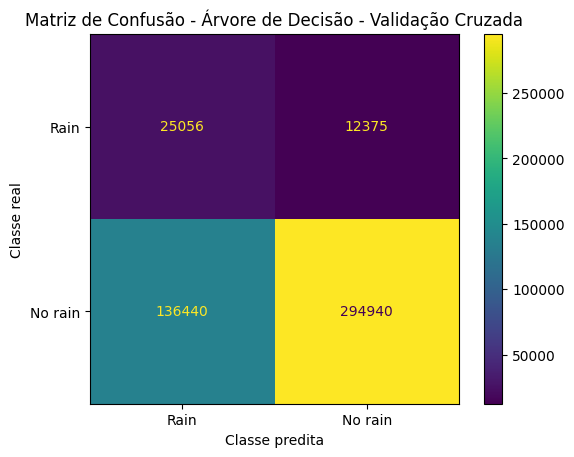

In [41]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_total.astype(int),
    display_labels=labels
).plot(values_format="d")

plt.title("Matriz de Confusão - Árvore de Decisão - Validação Cruzada")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")

plt.savefig("matriz_confusao_arvore_decisao.png", dpi=300, bbox_inches="tight")

plt.show()

AUC geral: 0.6943975407029522


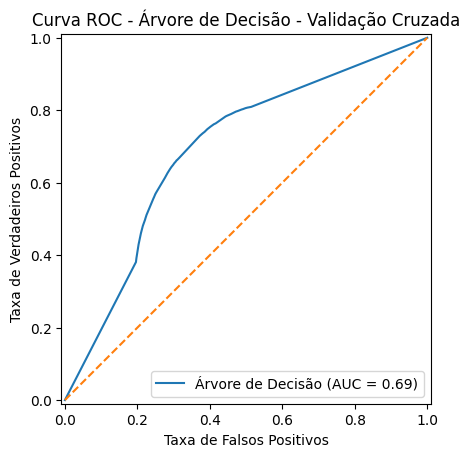

In [42]:
y_test_total = np.array(y_test_total)
y_prob_total = np.array(y_prob_total)

fpr, tpr, thresholds = roc_curve(y_test_total, y_prob_total)
auc = roc_auc_score(y_test_total, y_prob_total)

print("AUC geral:", auc)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc,
    estimator_name="Árvore de Decisão"
).plot()

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Árvore de Decisão - Validação Cruzada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")

plt.savefig("curva_roc_arvore_decisao.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
fim = time.perf_counter()

tempo_total = fim - inicio

horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

print(f"Tempo total do experimento: {horas}h {minutos}min {segundos:.2f}s")

Tempo total do experimento: 0h 0min 28.75s
